In [87]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report,  accuracy_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline

In [88]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [89]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Breast_cancer_dataset.csv')


In [90]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [91]:
# df = df.drop('Unnamed: 32', axis=1, inplace=True)
df.columns


Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [93]:
df = df.drop('id', axis=1)

In [94]:
df.sample(5)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
23,M,21.160,23.04,137.20,1404.0,0.09428,0.10220,0.109700,0.086320,0.1769,...,29.17,35.59,188.00,2615.0,0.1401,0.26000,0.31550,0.20090,0.2822,0.07526
247,B,12.890,14.11,84.95,512.2,0.08760,0.13460,0.137400,0.039800,0.1596,...,14.39,17.70,105.00,639.1,0.1254,0.58490,0.77270,0.15610,0.2639,0.11780
495,B,14.870,20.21,96.12,680.9,0.09587,0.08345,0.068240,0.049510,0.1487,...,16.01,28.48,103.90,783.6,0.1216,0.13880,0.17000,0.10170,0.2369,0.06599
97,B,9.787,19.94,62.11,294.5,0.10240,0.05301,0.006829,0.007937,0.1350,...,10.92,26.29,68.81,366.1,0.1316,0.09473,0.02049,0.02381,0.1934,0.08988
269,B,10.710,20.39,69.50,344.9,0.10820,0.12890,0.084480,0.028670,0.1668,...,11.69,25.21,76.51,410.4,0.1335,0.25500,0.25340,0.08600,0.2605,0.08701


In [121]:
ohe= OneHotEncoder(sparse_output=False)

In [122]:
ohe

OneHotEncoder(sparse_output=False)

In [124]:
dia_encoded = ohe.fit_transform(df[['diagnosis']])

In [125]:
ohe.get_feature_names_out()

array(['diagnosis_B', 'diagnosis_M'], dtype=object)

In [127]:
dia_df = pd.DataFrame(dia_encoded, columns=ohe.get_feature_names_out())

In [151]:
X = df.drop('diagnosis', axis=1)
y = dia_df['diagnosis_M']
#

In [141]:
y

,diagnosis_M
0,1.0
1,1.0
2,1.0
3,1.0
4,1.0
...,...
564,1.0
565,1.0
566,1.0
567,1.0


In [142]:
scaler = StandardScaler()

In [143]:
scale_df = scaler.fit_transform(X)

In [144]:
print(X.shape)
print(scale_df.shape)


(569, 30)
(569, 30)


In [145]:
pca = PCA(n_components=2)

In [146]:
data_pca = pca.fit_transform(scale_df)

In [152]:
pc_df = data_pca
pc_df

array([[ 9.19283683,  1.94858307],
       [ 2.3878018 , -3.76817174],
       [ 5.73389628, -1.0751738 ],
       ...,
       [ 1.25617928, -1.90229671],
       [10.37479406,  1.67201011],
       [-5.4752433 , -0.67063679]])

In [158]:
pc_df.shape

(569, 2)

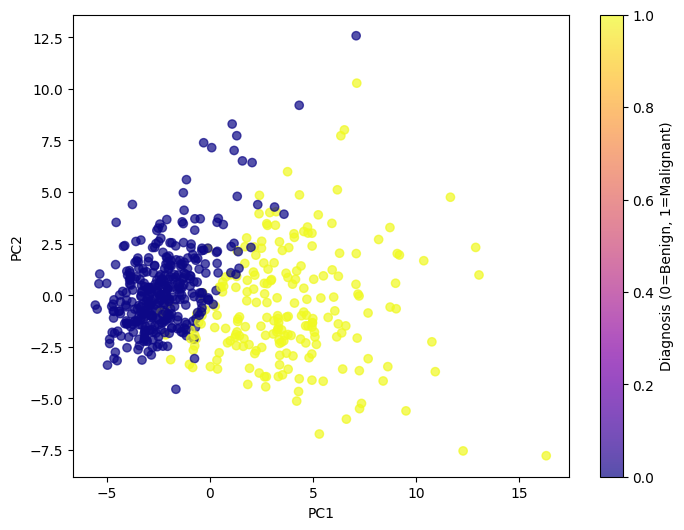

In [160]:
plt.figure(figsize=(8,6))
plt.scatter(
    pc_df[:, 0],
    pc_df[:, 1],
    c=y,
    cmap="plasma",
    alpha=0.7
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Diagnosis (0=Benign, 1=Malignant)")
plt.show()
